<a href="https://colab.research.google.com/github/amarachiosaji/amarachiosaji/blob/main/FRED.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install pandas_datareader yfinance

In [ ]:
import warnings; warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pandas_datareader import data as pdr

plt.rcParams["figure.figsize"] = (11, 4.5)

START = "1976-01-01"
END = None # None means "up to today"

In [ ]:
!pip install fredapi
from fredapi import Fred
fred = Fred(api_key="f8aae4e37923a44e447cc60e89d65e4b")

series = {
    "CPIAUCSL": "CPI",
    "UNRATE":   "Unemployment",
    "FEDFUNDS": "FedFunds",
    "INDPRO":   "IndProd",
    "DGS10":    "Yield10y",
    "T10Y2Y":   "Spread10y2y",
    "USREC":    "Recession",
    "GDPC1":    "RealGDP",

}

raw = pd.DataFrame({name: fred.get_series(code, observation_start=START)
                     for code, name in series.items()})
raw.tail()


,CPI,Unemployment,FedFunds,IndProd,Yield10y,Spread10y2y,Recession,RealGDP
2026-06-09,NaN,NaN,NaN,NaN,4.53,0.40,NaN,NaN
2026-06-10,NaN,NaN,NaN,NaN,4.55,0.42,NaN,NaN
2026-06-11,NaN,NaN,NaN,NaN,4.45,0.40,NaN,NaN
2026-06-12,NaN,NaN,NaN,NaN,4.48,0.39,NaN,NaN
2026-06-15,NaN,NaN,NaN,NaN,NaN,0.40,NaN,NaN


In [ ]:
m = raw.resample("ME").last() #this regroups the rows into month-end buckets
#.last() takes the final available value in each month
m.tail()

,CPI,Unemployment,FedFunds,IndProd,Yield10y,Spread10y2y,Recession,RealGDP
2026-02-28,327.460,4.4,3.64,101.9493,3.97,0.59,0.0,NaN
2026-03-31,330.293,4.3,3.64,101.6273,4.30,0.51,0.0,NaN
2026-04-30,332.407,4.3,3.64,102.5090,4.40,0.52,0.0,NaN
2026-05-31,333.979,4.3,3.63,102.6475,4.45,0.47,0.0,NaN
2026-06-30,NaN,NaN,NaN,NaN,4.48,0.40,NaN,NaN


In [ ]:
#here I'm forward-filling the GDP and building the TWO analytical columns that the whole regime analysis depends on.
m["RealGDP"] = m["RealGDP"].ffill()  #carry quarterly GDP across its 3 months

m["CPI_yoy"] = m["CPI"].pct_change(12) * 100  #inflation, % vs 12 months ago (YoY)
m["IndProd_yoy"] = m["IndProd"].pct_change(12) * 100  #activity growth, % YoY

m.tail()


,CPI,Unemployment,FedFunds,IndProd,Yield10y,Spread10y2y,Recession,RealGDP,CPI_yoy,IndProd_yoy
2026-02-28,327.460,4.4,3.64,101.9493,3.97,0.59,0.0,24152.656,2.434004,0.840758
2026-03-31,330.293,4.3,3.64,101.6273,4.30,0.51,0.0,24152.656,3.285958,0.580857
2026-04-30,332.407,4.3,3.64,102.5090,4.40,0.52,0.0,24152.656,3.779246,1.365696
2026-05-31,333.979,4.3,3.63,102.6475,4.45,0.47,0.0,24152.656,4.166615,1.665916
2026-06-30,NaN,NaN,NaN,NaN,4.48,0.40,NaN,24152.656,3.902500,1.151968


In [ ]:
#Here I'm trying to find out, "is inflation rising or falling relative to its own recent trend?"
#Measuring momemtum: the direction of travel.
m = m.dropna(subset=["CPI_yoy", "IndProd_yoy"])   # drop the first year (no YoY yet)

m["inverted"] = m["Spread10y2y"] < 0   # yield-curve inversion flag (True/False)
#Normally long-term bonds pay more than short-term ones (you demand extra yield to lock your money up longer), so the spread is positive. When it flips negative — short rates higher than long rates — that's a "yield curve inversion," and it's one of the most reliable recession warning signs in macro: it has preceded essentially every U.S. recession in the past ~50 years.
# Momentum: is each indicator above or below its own trailing 12-month average?
g = m["IndProd_yoy"] - m["IndProd_yoy"].rolling(12).mean()   # growth momentum
i = m["CPI_yoy"]     - m["CPI_yoy"].rolling(12).mean()       # inflation momentum

def quadrant(gr, inf):
    if pd.isna(gr) or pd.isna(inf): return np.nan
    if gr >= 0 and inf <  0: return "Recovery"      # growth up, inflation cooling
    if gr >= 0 and inf >= 0: return "Overheat"       # growth up, inflation rising
    if gr <  0 and inf >= 0: return "Stagflation"    # growth down, inflation rising
    return "Reflation/Slowdown"                      # growth down, inflation cooling
#The moment a return runs, the function exits immediately — nothing below it executes. So the logic reads like a checklist: "Is it NaN? If so, leave. Is it Recovery? If so, leave. Overheat? Leave. Stagflation? Leave." If execution survives all four checks without returning, there's only one possibility left — growth down and inflation down — so the final return "Reflation/Slowdown" is the catch-all.
#An else would be redundant because the earlier returns already guarantee we only reach that last line when nothing else matched. You could write it with elif/else and it would behave identically; this "early return" style is just a common, clean way to write it. Both are correct.


m["regime"] = [quadrant(a, b) for a, b in zip(g, i)]
m["regime"].value_counts()


,count
regime,
Reflation/Slowdown,179
Overheat,151
Stagflation,127
Recovery,126


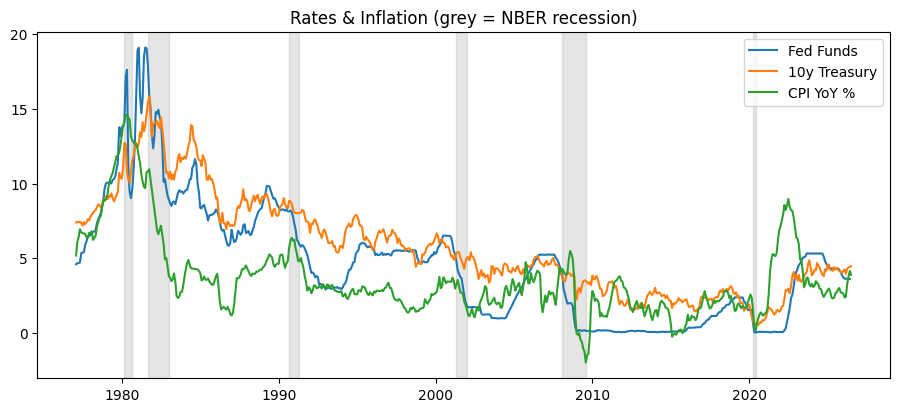

In [ ]:
#Chart 1:Overlays interest rates and inflation with grey bands marking historical recessions
def shade_recessions(ax, frame=m):  #walks through the months in order, watches the Recession column flip from 0 to 1(recession starts) and back to 0(recession ends), and paints a grey band over each of those stretches.
    rec = frame["Recession"].fillna(0).astype(int)
    inrec = False; start = None
    for date, val in rec.items():
        if val == 1 and not inrec:
            inrec, start = True, date
        elif val == 0 and inrec:
            ax.axvspan(start, date, color="grey", alpha=0.2); inrec = False
    if inrec:
        ax.axvspan(start, rec.index[-1], color="grey", alpha=0.2)

fig, ax = plt.subplots()
ax.plot(m.index, m["FedFunds"], label="Fed Funds")
ax.plot(m.index, m["Yield10y"], label="10y Treasury")
ax.plot(m.index, m["CPI_yoy"], label="CPI YoY %")
shade_recessions(ax)
ax.set_title("Rates & Inflation (grey = NBER recession)")
ax.legend()
plt.show()

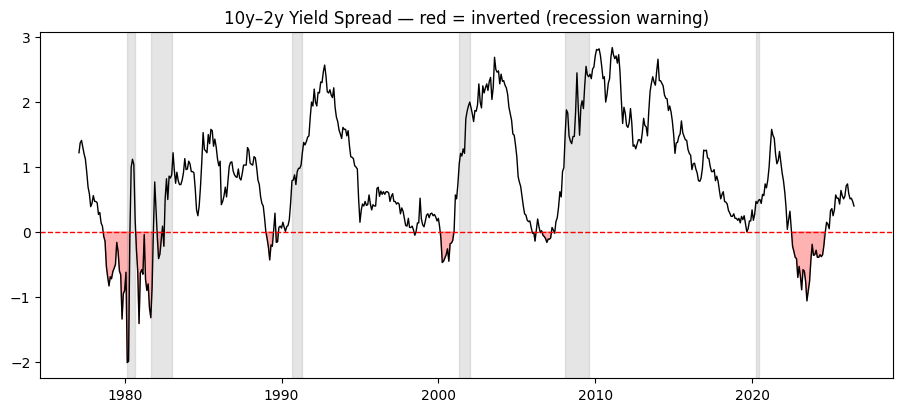

In [ ]:
#Chart 2: The yield curve inversion chart, the recession early-warning signal we built the inverted flag for.
#The inversion leads; the recession lags.

fig, ax = plt.subplots()
ax.plot(m.index, m["Spread10y2y"], color="black", lw=1)
ax.axhline(0, color="red", ls="--", lw=1)
ax.fill_between(m.index, m["Spread10y2y"], 0,
                where=m["Spread10y2y"] < 0, color="red", alpha=0.3)
shade_recessions(ax)
ax.set_title("10y–2y Yield Spread — red = inverted (recession warning)")
plt.show()

#The "did the recession follow this time?" question is one economists are actively debating right now

In [ ]:
#Here's what these charts mean for an investor
#How did the stock market actually perform in each regime?

import yfinance as yf

mkt_raw = yf.download("^GSPC", start=START, auto_adjust=True, progress=False)
sp500 = mkt_raw["Close"].squeeze()

m["SP500"] = sp500.resample("ME").last()     # align to your monthly grid
m["SP500_ret"] = m["SP500"].pct_change()       # monthly return

m[["SP500", "SP500_ret", "regime"]].tail()

,SP500,SP500_ret,regime
2026-02-28,6878.879883,-0.008668,Reflation/Slowdown
2026-03-31,6528.520020,-0.050933,Stagflation
2026-04-30,7209.009766,0.104233,Overheat
2026-05-31,7580.060059,0.051470,Overheat
2026-06-30,7529.569824,-0.006661,Stagflation


In [ ]:
#Final table:

def annualized_stats(returns):
    return pd.Series({
        "months":      returns.count(),
        "ann_return%": returns.mean() * 12 * 100,
        "ann_vol%":    returns.std() * np.sqrt(12) * 100,
        "sharpe":      (returns.mean() * 12) / (returns.std() * np.sqrt(12) + 1e-9),
    })

by_regime = m.groupby("regime")["SP500_ret"].apply(annualized_stats).unstack()
order = ["Recovery", "Overheat", "Stagflation", "Reflation/Slowdown"]
by_regime = by_regime.reindex([r for r in order if r in by_regime.index])
by_regime.round(2)

,months,ann_return%,ann_vol%,sharpe
regime,,,,
Recovery,126.0,11.90,13.79,0.86
Overheat,151.0,10.19,14.16,0.72
Stagflation,127.0,1.86,15.54,0.12
Reflation/Slowdown,179.0,14.88,16.23,0.92


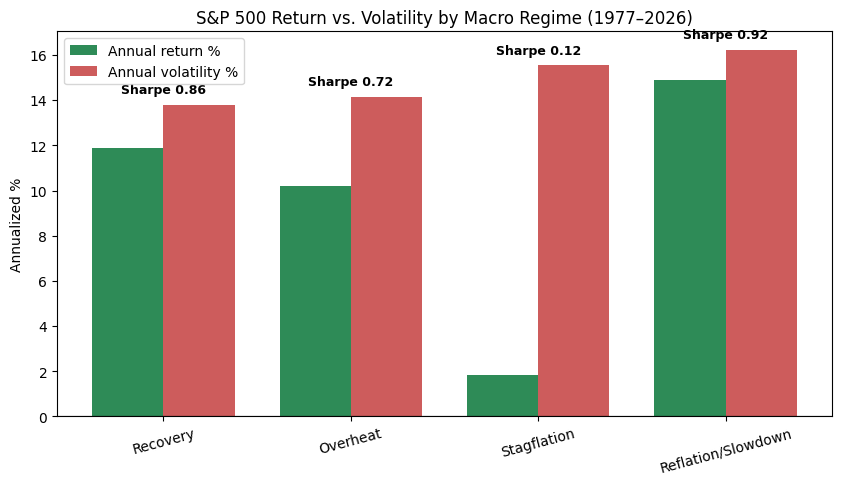

In [ ]:
#A chart of the regime table

fig, ax = plt.subplots(figsize=(10, 5))

x = np.arange(len(by_regime))
w = 0.38

ax.bar(x - w/2, by_regime["ann_return%"], w, label="Annual return %", color="seagreen")
ax.bar(x + w/2, by_regime["ann_vol%"],    w, label="Annual volatility %", color="indianred")

# Sharpe ratio labeled above each pair
for i, s in enumerate(by_regime["sharpe"]):
    ax.text(i, max(by_regime["ann_return%"].iloc[i], by_regime["ann_vol%"].iloc[i]) + 0.5,
            f"Sharpe {s:.2f}", ha="center", fontsize=9, fontweight="bold")

ax.axhline(0, color="black", lw=0.8)
ax.set_xticks(x)
ax.set_xticklabels(by_regime.index, rotation=15)
ax.set_title("S&P 500 Return vs. Volatility by Macro Regime (1977–2026)")
ax.set_ylabel("Annualized %")
ax.legend()
plt.show()

In [ ]:
#Why the Reflation/Slowdown is strong

m["fed_cutting"] = m["FedFunds"].diff() < 0   # True when rate fell vs prior month

cut_share = m.groupby("regime")["fed_cutting"].mean() * 100
print("Share of months when the Fed was cutting rates, by regime:\n")
print(cut_share.round(1).astype(str) + "%")



#We see that Reflation/Slowdown: in that regime the economy is cooling and inflation is falling, which gives the Fed room to cut, and those cuts are exactly the tailwind that lifts stocks even as growth softens.

Share of months when the Fed was cutting rates, by regime:

regime
Overheat              26.5%
Recovery              35.7%
Reflation/Slowdown    49.7%
Stagflation           36.2%
Name: fed_cutting, dtype: object
